# Part 01 - Data Understanding, Cleaning & Customer Behaviour Analysis

This notebook covers the first stage of the Customer Lifetime Value project.

The goal is to understand the retail transaction data, identify data quality issues, clean the transaction records, and explore customer purchasing behaviour before moving to customer-level CLV analysis.

## 1. Load the Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Inspect the Excel Workbook

The dataset is provided as an Excel workbook containing transactions from two yearly periods.

Before loading the transaction data, the available sheets will be checked.

In [2]:
file_path = "../data/raw/online_retail_dataset.xlsx"

excel_file = pd.ExcelFile(file_path)

excel_file.sheet_names

['Year 2009-2010', 'Year 2010-2011']

## 3. Inspect the Transaction Sheets

The workbook contains two yearly transaction sheets.

Before combining them, each sheet will be inspected separately to understand its structure, columns, and sample records.

In [3]:
data_2009_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010",
    nrows=5
)

data_2009_2010

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


In [4]:
data_2010_2011 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011",
    nrows=5
)

data_2010_2011

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


## 4. Load and Check Sheet Structure

The two transaction sheets will now be loaded separately to check their row counts, columns, and data types before combining them.

In [5]:
data_2009_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

data_2009_2010.shape

(525461, 8)

### 4.1 Check Data Types

The data types of each column will be checked before further cleaning and transformation.

In [6]:
data_2009_2010.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

In [7]:
data_2010_2011 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

data_2010_2011.shape

(541910, 8)

In [8]:
data_2010_2011.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

## 5. Check Missing Values

Missing values will be checked separately in each transaction sheet to understand whether any columns contain incomplete records.

In [9]:
data_2009_2010.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [10]:
data_2010_2011.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

## 6. Check Duplicate Transactions

Duplicate rows will be checked separately in each transaction sheet to determine whether the raw data contains repeated transaction records.

In [11]:
data_2009_2010.duplicated().sum()

np.int64(6865)

In [12]:
data_2010_2011.duplicated().sum()

np.int64(5268)

## 7. Investigate Cancelled Transactions

Transaction cancellations will be investigated before cleaning.

The invoice values will be examined to identify whether cancelled transactions follow a specific pattern in the raw data.

In [13]:
data_2009_2010["Invoice"].astype(str).str.startswith("C").sum()

np.int64(10206)

In [14]:
data_2010_2011["Invoice"].astype(str).str.startswith("C").sum()

np.int64(9288)

### 7.1 Inspect Cancelled Transaction Records

A sample of records with invoice values beginning with `C` will be inspected to understand their quantities, prices, and other transaction details.

In [15]:
cancelled_2009_2010 = data_2009_2010[
    data_2009_2010["Invoice"].astype(str).str.startswith("C")
]

cancelled_2009_2010.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


### 7.2 Inspect Cancelled Transactions in 2010-2011

The same cancellation pattern will be checked in the second transaction sheet.

In [16]:
cancelled_2010_2011 = data_2010_2011[
    data_2010_2011["Invoice"].astype(str).str.startswith("C")
]

cancelled_2010_2011.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
937,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


## 8. Check Negative Quantities

Negative quantities will be measured separately from invoice prefixes to understand how many transaction records contain quantities below zero.

In [17]:
(data_2009_2010["Quantity"] < 0).sum()

np.int64(12326)

In [18]:
(data_2010_2011["Quantity"] < 0).sum()

np.int64(10624)

## 9. Check Zero Quantities

Zero quantities will be checked separately because they do not represent a positive or negative quantity movement and may require further investigation.

In [19]:
(data_2009_2010["Quantity"] == 0).sum()

np.int64(0)

In [20]:
(data_2010_2011["Quantity"] == 0).sum()

np.int64(0)

## 10. Check Unit Prices

Unit prices will be checked for unusual values.

The first check will identify transactions with negative prices, which may indicate invalid or special transaction records.

In [21]:
(data_2009_2010["Price"] < 0).sum()

np.int64(3)

In [22]:
(data_2010_2011["Price"] < 0).sum()

np.int64(2)

### 10.1 Inspect Negative-Price Transactions

The records with negative unit prices will be inspected to determine whether these values represent data errors or special transaction records.

In [23]:
negative_price_2009_2010 = data_2009_2010[
    data_2009_2010["Price"] < 0
]

negative_price_2009_2010

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


### 10.2 Inspect Negative-Price Transactions in 2010-2011

The records with negative unit prices in the second transaction sheet will be inspected to determine whether they follow the same adjustment pattern.

In [24]:
negative_price_2010_2011 = data_2010_2011[
    data_2010_2011["Price"] < 0
]

negative_price_2010_2011

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


## 11. Check Zero Prices

Zero unit prices will be checked to identify transactions that may represent free items, adjustments, or other special records.

In [25]:
(data_2009_2010["Price"] == 0).sum()

np.int64(3687)

## 11. Check Zero Prices

Zero unit prices will be checked to identify transactions that may represent free items, adjustments, or other special records.

In [26]:
(data_2009_2010["Price"] == 0).sum()

np.int64(3687)

In [27]:
(data_2010_2011["Price"] == 0).sum()

np.int64(2515)

In [28]:
zero_price_2009_2010 = data_2009_2010[
    data_2009_2010["Price"] == 0
]

zero_price_2009_2010.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom


In [29]:
zero_price_2010_2011 = data_2010_2011[
    data_2010_2011["Price"] == 0
]

zero_price_2010_2011.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1510,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1985,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1986,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
2022,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2023,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


## 12. Numerical Summary

The main numerical transaction fields will be summarized to understand their overall ranges and distribution before cleaning.

In [30]:
data_2009_2010[["Quantity", "Price"]].describe()

,Quantity,Price
count,525461.000000,525461.000000
mean,10.337667,4.688834
std,107.424110,146.126914
min,-9600.000000,-53594.360000
25%,1.000000,1.250000
50%,3.000000,2.100000
75%,10.000000,4.210000
max,19152.000000,25111.090000


In [31]:
data_2010_2011[["Quantity", "Price"]].describe()

,Quantity,Price
count,541910.000000,541910.000000
mean,9.552234,4.611138
std,218.080957,96.759765
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


## 13. Combine the Transaction Sheets

The two yearly transaction sheets have the same columns and compatible data types, so they will now be combined into a single transaction dataset.

In [32]:
transactions = pd.concat(
    [data_2009_2010, data_2010_2011],
    ignore_index=True
)

transactions.shape

(1067371, 8)

In [33]:
transactions.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [34]:
transactions.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


## 14. Audit the Combined Transaction Dataset

The combined dataset will be audited again to confirm its structure and identify data-quality issues across the full transaction period.

In [35]:
transactions.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

In [36]:
transactions.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [37]:
transactions.duplicated().sum()

np.int64(34335)

In [38]:
transactions.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


## 15. Investigate Negative Quantities

Negative quantities that do not have a cancellation invoice prefix will be inspected separately.

This helps determine whether they represent returns or other non-standard transaction records.

In [39]:
cancellation_mask = transactions["Invoice"].astype(str).str.startswith("C")

negative_quantity_mask = transactions["Quantity"] < 0

negative_quantity_not_cancelled = (
    negative_quantity_mask & ~cancellation_mask
)

negative_quantity_not_cancelled.sum()

np.int64(3457)

In [40]:
transactions.loc[
    negative_quantity_not_cancelled,
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "Price",
        "Customer ID",
        "Country"
    ]
].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom
4538,489820,21133,invcd as 84879?,-720,2009-12-02 13:23:00,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom


## 16. Clean the Transaction Dataset

A separate cleaned transaction dataset will be created.

The cleaning will:

- Remove exact duplicate rows
- Remove cancelled invoices
- Remove transactions without a Customer ID
- Keep only positive quantities
- Keep only positive unit prices

These rules are intended to create a transaction dataset containing completed, customer-linked, revenue-generating purchases for the later CLV analysis.

In [41]:
cleaned_transactions = transactions.copy()

In [42]:
cleaned_transactions = cleaned_transactions.drop_duplicates()

In [43]:
cleaned_transactions = cleaned_transactions[
    ~cleaned_transactions["Invoice"].astype(str).str.startswith("C")
]

In [44]:
cleaned_transactions = cleaned_transactions.dropna(
    subset=["Customer ID"]
)

In [45]:
cleaned_transactions = cleaned_transactions[
    cleaned_transactions["Quantity"] > 0
]

In [46]:
cleaned_transactions = cleaned_transactions[
    cleaned_transactions["Price"] > 0
]

## 17. Prepare Customer ID

Customer IDs are identifiers rather than continuous numerical measurements, so they will be stored as integers after missing values have been removed.

In [47]:
cleaned_transactions["Customer ID"] = (
    cleaned_transactions["Customer ID"].astype("int64")
)

In [48]:
cleaned_transactions.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID             int64
Country                object
dtype: object

## 18. Calculate Transaction Value

The total value of each transaction line will be calculated by multiplying quantity by unit price.

In [49]:
cleaned_transactions["TotalPrice"] = (
    cleaned_transactions["Quantity"] *
    cleaned_transactions["Price"]
)

In [50]:
cleaned_transactions[
    [
        "Invoice",
        "Quantity",
        "Price",
        "TotalPrice"
    ]
].head(10)

,Invoice,Quantity,Price,TotalPrice
0,489434,12,6.95,83.4
1,489434,12,6.75,81.0
2,489434,12,6.75,81.0
3,489434,48,2.10,100.8
4,489434,24,1.25,30.0
5,489434,24,1.65,39.6
6,489434,24,1.25,30.0
7,489434,10,5.95,59.5
8,489435,12,2.55,30.6
9,489435,12,3.75,45.0


## 19. Validate the Cleaned Dataset

The cleaned transaction dataset will be checked to confirm that the cleaning rules were applied correctly.

In [51]:
cleaned_transactions.shape

(779425, 9)

In [52]:
cleaned_transactions.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
TotalPrice     0
dtype: int64

In [53]:
cleaned_transactions.duplicated().sum()

np.int64(0)

In [54]:
(cleaned_transactions["Quantity"] <= 0).sum()

np.int64(0)

In [55]:
(cleaned_transactions["Price"] <= 0).sum()

np.int64(0)

In [56]:
cleaned_transactions["TotalPrice"].describe()

count    779425.000000
mean         22.291823
std         227.427075
min           0.001000
25%           4.950000
50%          12.480000
75%          19.800000
max      168469.600000
Name: TotalPrice, dtype: float64

## 20. Cleaning Impact

The number of records before and after cleaning will be compared to understand how much of the raw transaction data was removed.

In [57]:
cleaning_summary = pd.DataFrame({
    "Stage": [
        "Raw combined data",
        "After cleaning"
    ],
    "Rows": [
        len(transactions),
        len(cleaned_transactions)
    ]
})

cleaning_summary

,Stage,Rows
0,Raw combined data,1067371
1,After cleaning,779425


In [58]:
removed_rows = len(transactions) - len(cleaned_transactions)

removed_rows

287946

In [59]:
removed_percentage = (
    removed_rows / len(transactions)
) * 100

removed_percentage

26.97712416769802

## 21. Customer Purchasing Behaviour

The cleaned transaction data will be used to understand basic customer purchasing behaviour before customer-level CLV feature engineering.

In [60]:
cleaned_transactions["InvoiceDate"].min(), cleaned_transactions["InvoiceDate"].max()

(Timestamp('2009-12-01 07:45:00'), Timestamp('2011-12-09 12:50:00'))

In [61]:
cleaned_transactions["Customer ID"].nunique()

5878

In [62]:
cleaned_transactions["Invoice"].nunique()

36969

In [63]:
cleaned_transactions["TotalPrice"].sum()

np.float64(17374804.268)

## 22. Customer-Level Purchasing Summary

Transaction data will be aggregated to the customer level to understand purchase frequency, spending, and average transaction value.

In [64]:
customer_summary = (
    cleaned_transactions
    .groupby("Customer ID")
    .agg(
        total_spend=("TotalPrice", "sum"),
        total_transactions=("Invoice", "nunique"),
        total_items=("Quantity", "sum"),
        average_transaction_value=("TotalPrice", "mean"),
        first_purchase=("InvoiceDate", "min"),
        last_purchase=("InvoiceDate", "max")
    )
    .reset_index()
)

customer_summary.head()

,Customer ID,total_spend,total_transactions,total_items,average_transaction_value,first_purchase,last_purchase
0,12346,77556.46,12,74285,2281.072353,2009-12-14 08:34:00,2011-01-18 10:01:00
1,12347,4921.53,8,2967,22.169054,2010-10-31 14:20:00,2011-12-07 15:52:00
2,12348,2019.40,5,2714,39.596078,2010-09-27 14:59:00,2011-09-25 13:13:00
3,12349,4428.69,4,1624,25.306800,2010-04-29 13:20:00,2011-11-21 09:51:00
4,12350,334.40,1,197,19.670588,2011-02-02 16:01:00,2011-02-02 16:01:00


In [65]:
customer_summary.describe()

,Customer ID,total_spend,total_transactions,total_items,average_transaction_value,first_purchase,last_purchase
count,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878,5878
mean,15315.313542,2955.904095,6.289384,1788.695475,48.301822,2010-08-22 06:57:33.297039616,2011-05-22 16:19:59.469207296
min,12346.000000,2.950000,1.000000,1.000000,2.135778,2009-12-01 07:45:00,2009-12-01 09:55:00
25%,13833.250000,342.280000,1.000000,187.000000,11.564180,2010-02-09 14:01:15,2010-11-25 10:24:45
50%,15314.500000,867.740000,3.000000,480.000000,17.367639,2010-06-27 13:31:30,2011-09-05 11:59:00
75%,16797.750000,2248.305000,7.000000,1350.000000,24.181900,2011-01-30 14:30:15,2011-11-14 11:31:15
max,18287.000000,580987.040000,398.000000,367193.000000,56157.500000,2011-12-09 12:16:00,2011-12-09 12:50:00
std,1715.572666,14440.852688,13.009406,8876.297196,780.176769,NaN,NaN


## 23. Top Customers by Spending

The customers with the highest recorded transaction value will be reviewed to understand the distribution of customer spending.

In [66]:
top_customers = (
    customer_summary
    .sort_values("total_spend", ascending=False)
    .head(10)
)

top_customers

,Customer ID,total_spend,total_transactions,total_items,average_transaction_value,first_purchase,last_purchase
5692,18102,580987.04,145,181645,558.641385,2009-12-01 09:24:00,2011-12-09 11:50:00
2277,14646,528602.52,151,367193,137.335027,2009-12-02 16:52:00,2011-12-08 12:12:00
1789,14156,313437.62,156,164325,77.621996,2009-12-01 12:30:00,2011-11-30 10:54:00
2538,14911,291420.81,398,147972,26.308640,2009-12-01 11:41:00,2011-12-08 15:54:00
5050,17450,244784.25,51,83914,582.819643,2010-09-27 16:59:00,2011-12-01 13:29:00
1331,13694,195640.69,143,188201,128.795714,2009-12-04 15:26:00,2011-12-06 09:32:00
5109,17511,172132.87,60,117174,92.148217,2009-12-02 10:52:00,2011-12-07 10:12:00
4061,16446,168472.50,2,80997,56157.500000,2011-05-18 09:52:00,2011-12-09 09:15:00
4295,16684,147142.77,55,104810,204.934220,2009-12-07 12:56:00,2011-12-05 14:06:00
68,12415,144458.37,28,91447,156.002559,2010-06-30 08:30:00,2011-11-15 14:22:00


## 24. Purchasing Behaviour by Country

Transaction value will be summarized by country to understand where the recorded sales originate.

In [67]:
country_summary = (
    cleaned_transactions
    .groupby("Country")
    .agg(
        total_spend=("TotalPrice", "sum"),
        transactions=("Invoice", "nunique"),
        customers=("Customer ID", "nunique")
    )
    .sort_values("total_spend", ascending=False)
)

country_summary.head(10)

,total_spend,transactions,customers
Country,,,
United Kingdom,1.438923e+07,33541,5350
EIRE,6.165705e+05,567,5
Netherlands,5.540381e+05,228,22
Germany,4.250197e+05,789,107
France,3.487690e+05,614,95
Australia,1.692835e+05,95,15
Spain,1.083325e+05,154,41
Switzerland,1.000619e+05,90,22
Sweden,9.151582e+04,104,19


## 25. Monthly Revenue Trend

Monthly transaction value will be calculated to understand how recorded sales changed over the observation period.

In [68]:
monthly_revenue = (
    cleaned_transactions
    .set_index("InvoiceDate")
    .resample("ME")["TotalPrice"]
    .sum()
)

monthly_revenue.head()

InvoiceDate
2009-12-31    683504.010
2010-01-31    555802.672
2010-02-28    504558.956
2010-03-31    696978.471
2010-04-30    591982.002
Freq: ME, Name: TotalPrice, dtype: float64

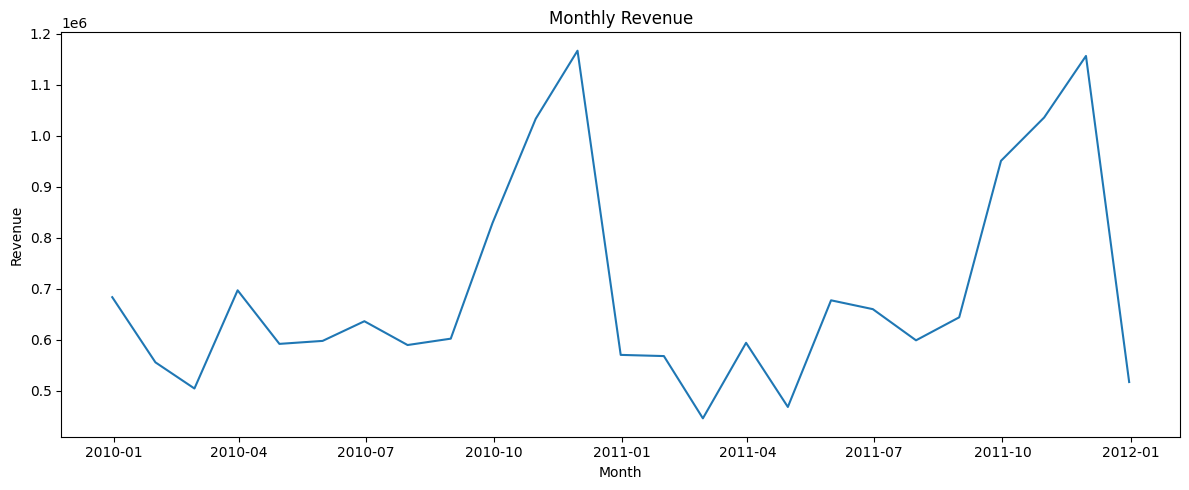

In [69]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()
plt.savefig(
    "../images/01_monthly_revenue.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 26. Monthly Active Customers

The number of unique customers making purchases each month will be examined to understand customer activity over time.

In [70]:
monthly_customers = (
    cleaned_transactions
    .set_index("InvoiceDate")
    .resample("ME")["Customer ID"]
    .nunique()
)

monthly_customers.head()

InvoiceDate
2009-12-31     955
2010-01-31     720
2010-02-28     772
2010-03-31    1057
2010-04-30     942
Freq: ME, Name: Customer ID, dtype: int64

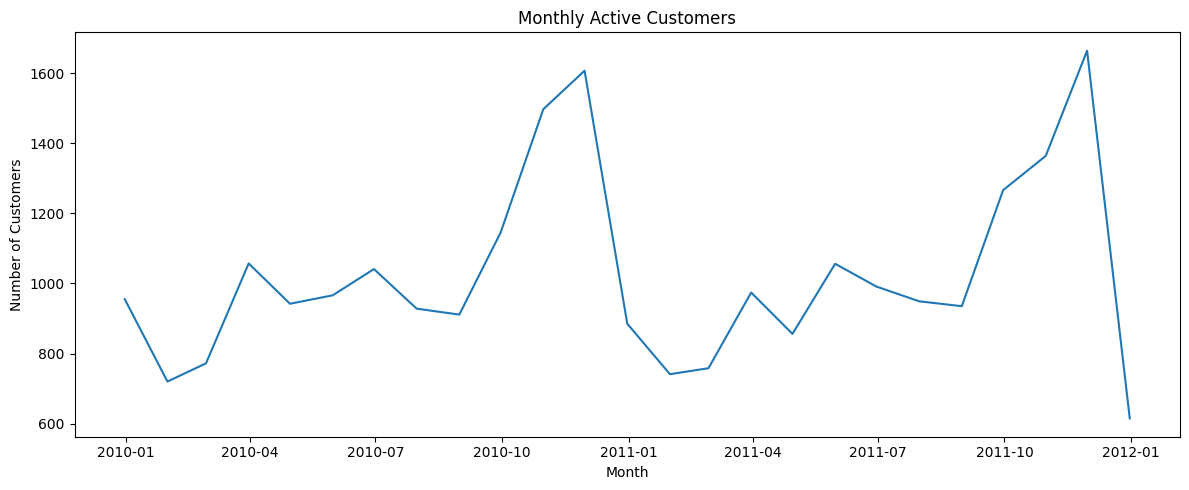

In [71]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_customers.index,
    monthly_customers.values
)

plt.title("Monthly Active Customers")
plt.xlabel("Month")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig(
    "../images/02_monthly_active_customers.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

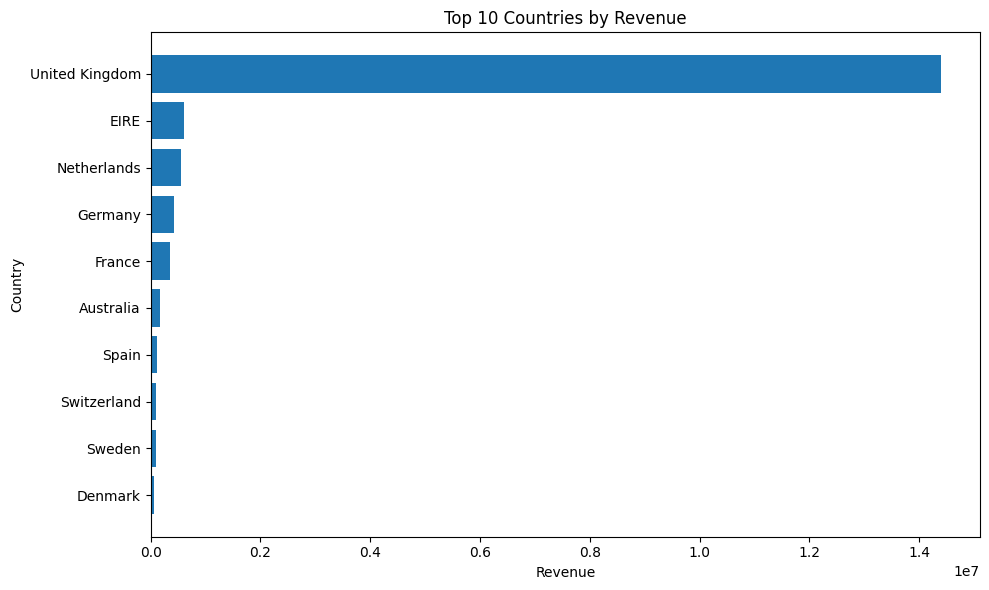

In [72]:
top_countries = (
    country_summary
    .head(10)
    .sort_values("total_spend")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_countries.index,
    top_countries["total_spend"]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.savefig(
    "../images/03_top_countries_by_revenue.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 28. Save the Cleaned Transaction Dataset

The validated transaction-level dataset will be saved in the processed data directory for use in the next stage of the CLV project.

In [73]:
output_path = "../data/processed/cleaned_transactions.csv"

cleaned_transactions.to_csv(
    output_path,
    index=False
)

In [74]:
output_path

'../data/processed/cleaned_transactions.csv'

## 29. Final Validation

The processed dataset will be checked one final time before this stage is considered complete.

In [75]:
final_check = {
    "rows": len(cleaned_transactions),
    "columns": cleaned_transactions.shape[1],
    "missing_customer_ids": cleaned_transactions["Customer ID"].isnull().sum(),
    "duplicate_rows": cleaned_transactions.duplicated().sum(),
    "non_positive_quantity": (cleaned_transactions["Quantity"] <= 0).sum(),
    "non_positive_price": (cleaned_transactions["Price"] <= 0).sum(),
    "unique_customers": cleaned_transactions["Customer ID"].nunique(),
    "unique_invoices": cleaned_transactions["Invoice"].nunique(),
    "total_revenue": cleaned_transactions["TotalPrice"].sum()
}

final_check

{'rows': 779425,
 'columns': 9,
 'missing_customer_ids': np.int64(0),
 'duplicate_rows': np.int64(0),
 'non_positive_quantity': np.int64(0),
 'non_positive_price': np.int64(0),
 'unique_customers': 5878,
 'unique_invoices': 36969,
 'total_revenue': np.float64(17374804.268)}